# Part II - Explanatory Data Analysis Ford GoBike Bike Sharing Dataset By Rakesh Ravula



## Introduction

This project analyzes the Ford GoBike bike-sharing dataset for February 2019. The dataset contains information about bike trips, including trip duration, start and end times, user type, rider demographics, and station locations.

The objective of this analysis is to identify important travel patterns, understand customer behavior, and explore how trip characteristics vary across different user groups.

Dataset Source:
https://www.fordgobike.com/system-data

## Key Questions

This presentation focuses on answering the following questions:

1. What is the distribution of trip durations?
2. Which hours of the day have the highest number of trips?
3. How does user type affect trip duration?
4. How does age influence riding behavior?
5. What are the major insights that can help understand customer usage?

## Summary of Findings

The exploratory analysis revealed several important insights:

- Most bike trips last less than 20 minutes.
- Bike usage peaks during morning and evening commuting hours.
- Subscribers use the service much more frequently than customers.
- Younger riders generally make shorter trips.
- Trip duration is highly right-skewed, making logarithmic scaling more suitable for visualization.

#  Choose ONLY 3–5 Best Visualizations

Do NOT include every graph from Part I.

Use only your strongest plots.

Recommended order:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("201902-fordgobike-tripdata.csv")

In [5]:
# Create a copy
df_clean = df.copy()

# Convert datetime columns
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'])
df_clean['end_time'] = pd.to_datetime(df_clean['end_time'])

# Create duration in minutes
df_clean['duration_min'] = df_clean['duration_sec'] / 60

# Create start hour
df_clean['start_hour'] = df_clean['start_time'].dt.hour

# Create age
df_clean['age'] = 2019 - df_clean['member_birth_year']

# Remove missing ages
df_clean = df_clean.dropna(subset=['member_birth_year'])

# Remove age outliers
df_clean = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 80)]

# Remove trip duration outliers (trips longer than 60 minutes)
df_clean = df_clean[df_clean['duration_min'] <= 60]

In [6]:
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 173565 entries, 4 to 183411
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             173565 non-null  int64         
 1   start_time               173565 non-null  datetime64[ns]
 2   end_time                 173565 non-null  datetime64[ns]
 3   start_station_id         173374 non-null  float64       
 4   start_station_name       173374 non-null  object        
 5   start_station_latitude   173565 non-null  float64       
 6   start_station_longitude  173565 non-null  float64       
 7   end_station_id           173374 non-null  float64       
 8   end_station_name         173374 non-null  object        
 9   end_station_latitude     173565 non-null  float64       
 10  end_station_longitude    173565 non-null  float64       
 11  bike_id                  173565 non-null  int64         
 12  user_type            

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,duration_min,start_hour,age
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,26.416667,23,45.0
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,29.883333,23,60.0
6,1147,2019-02-28 23:55:35.104,2019-03-01 00:14:42.588,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No,19.116667,23,36.0
7,1615,2019-02-28 23:41:06.766,2019-03-01 00:08:02.756,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No,26.916667,23,30.0
8,1570,2019-02-28 23:41:48.790,2019-03-01 00:07:59.715,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No,26.166667,23,31.0


# Visualization 1
Distribution of Trip Duration

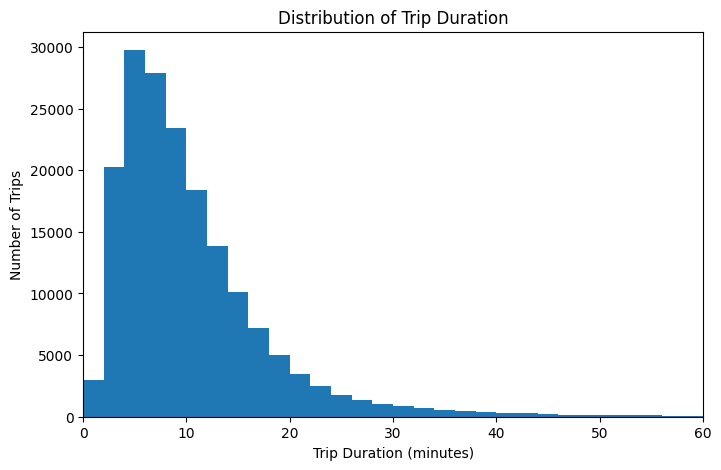

In [7]:
plt.figure(figsize=(8,5))

bins = np.arange(0, df_clean['duration_min'].max()+1, 2)

plt.hist(df_clean['duration_min'], bins=bins)

plt.xlim(0,60)

plt.title('Distribution of Trip Duration')

plt.xlabel('Trip Duration (minutes)')

plt.ylabel('Number of Trips')

plt.show()

Most trips last between 5 and 15 minutes, indicating that the bike-sharing system is primarily used for short-distance travel.

# Visualization 2

Peak Riding Hours

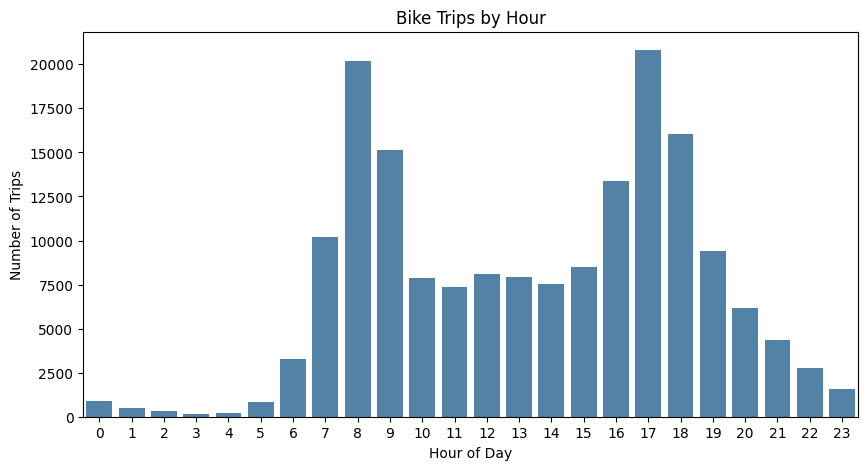

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(data=df_clean,
              x='start_hour',
              color='steelblue')

plt.title('Bike Trips by Hour')

plt.xlabel('Hour of Day')

plt.ylabel('Number of Trips')

plt.show()

Trip activity peaks around 8 AM and 5–6 PM, suggesting that bikes are widely used for daily commuting.

# Visualization 3

Subscriber vs Customer

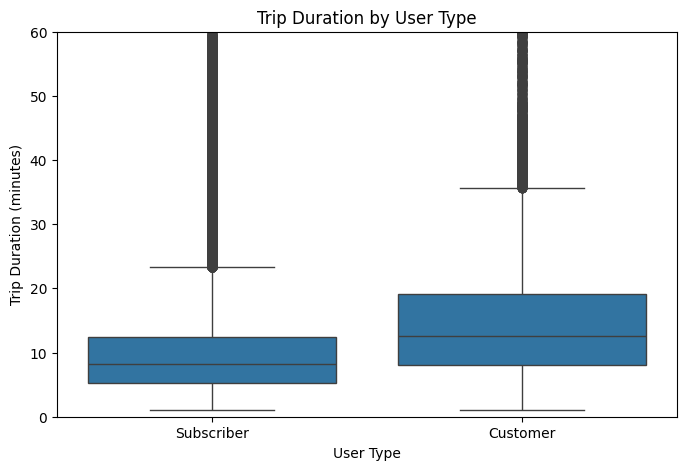

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean,
            x='user_type',
            y='duration_min')

plt.ylim(0,60)

plt.title('Trip Duration by User Type')

plt.xlabel('User Type')

plt.ylabel('Trip Duration (minutes)')

plt.show()

Customers tend to take longer trips than subscribers, while subscribers make shorter and more consistent trips.

 # Visualization 4

Age vs Duration

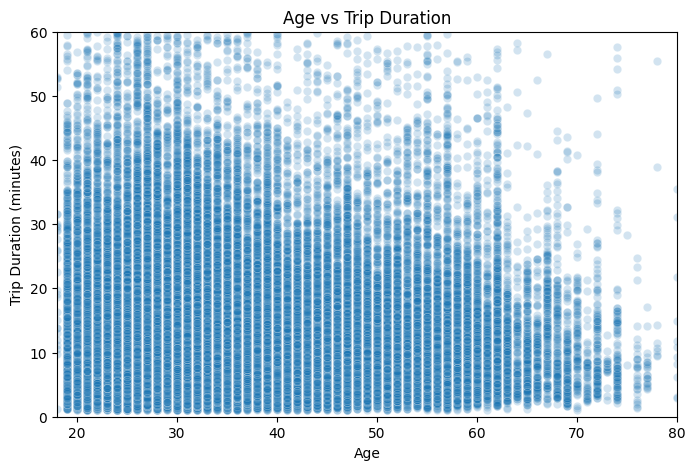

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df_clean,
                x='age',
                y='duration_min',
                alpha=0.2)

plt.xlim(18,80)

plt.ylim(0,60)

plt.title('Age vs Trip Duration')

plt.xlabel('Age')

plt.ylabel('Trip Duration (minutes)')

plt.show()

No strong relationship exists between rider age and trip duration, although younger riders appear to use the service more frequently.

# Visualization 5 

Subscriber Percentage

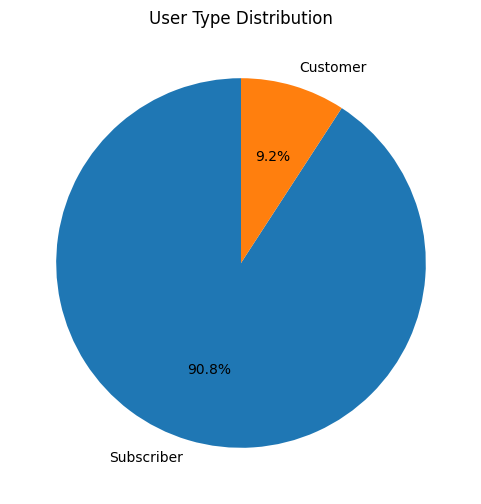

In [11]:
plt.figure(figsize=(6,6))

df_clean['user_type'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')

plt.title('User Type Distribution')

plt.show()

Subscribers account for the majority of bike trips, indicating that regular commuters dominate system usage.

# Conclusions

The Ford GoBike system is primarily used for short daily trips. Usage is highest during weekday commuting hours, indicating that many riders depend on the service for transportation rather than leisure.

Subscribers make the majority of trips and generally ride for shorter durations than customers. Although rider age has little impact on trip duration, the dataset suggests that younger adults are the primary users.

Overall, the bike-sharing system effectively supports urban commuting by providing a convenient option for short-distance travel.